# Neural Network Models for S&P 500 Return Prediction

This notebook implements and compares **four neural network architectures** for predicting S&P 500 returns using macroeconomic and lagged features.

---




> **Target variable:** S&P 500 forward returns (next period)  
> **Framework:** TensorFlow / Keras  

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from tensorflow.keras.optimizers import Adam

import keras_tuner as kt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


In [2]:
from pathlib import Path
import sys
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.data_preprocessing import data_split


In [3]:

FEATURE_COLS = [
    'CPI_Change_lag1', 'Rate_Change', 'GDP_Growth_lag2', 'Unemp_Change_lag1',
    'USD_Change', 'VIX_Change', 'Credit_Spread_lag2']

df = pd.read_csv('../data/processed/processed_data.csv', parse_dates=['Date'])

splits_data = data_split(df, FEATURE_COLS)
X_train_raw = splits_data['X_train']
y_train     = splits_data['y_train']
X_test_raw  = splits_data['X_test']
y_test      = splits_data['y_test']

# Scale — fit on train only
scaler_macro = StandardScaler()
X_train      = scaler_macro.fit_transform(X_train_raw)
X_test       = scaler_macro.transform(X_test_raw)

print(f"\nTrain shape : {X_train.shape}")
print(f"Test  shape : {X_test.shape}")






  Features (7): CPI_Change_lag1, Rate_Change, GDP_Growth_lag2, Unemp_Change_lag1, USD_Change, VIX_Change, Credit_Spread_lag2

Train shape : (346, 7)
Test  shape : (69, 7)


In [4]:
def plot_loss_curve(history, model_name):
    """Plot train vs validation loss."""
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['rmse'],     label='Train RMSE', color='blue')
    plt.plot(history.history['val_rmse'], label='Val RMSE',   color='orange')

    best_epoch = int(np.argmin(history.history['val_rmse'])) + 1
    plt.axvline(best_epoch, color='red', linestyle='--',
                label=f'Best Epoch = {best_epoch}')

    plt.xlabel('Epoch')
    plt.ylabel('RMSE')
    plt.title(f'{model_name} — Train vs Validation RMSE')
    plt.legend()
    plt.tight_layout()
    plt.show()


In [5]:
def plot_stability(results):
    """Plot RMSE and R² across runs."""
    model_name = results['model_name']
    test_rmses = results['test_rmses']
    test_r2s   = results['test_r2s']
    n_runs     = len(test_rmses)
    runs       = range(1, n_runs + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # RMSE
    axes[0].bar(runs, test_rmses, color='steelblue', alpha=0.7, label='Test RMSE')
    axes[0].axhline(np.mean(test_rmses), color='red', linestyle='--',
                    label=f'Mean: {np.mean(test_rmses):.4f}')
    axes[0].fill_between(runs,
                          np.mean(test_rmses) - np.std(test_rmses),
                          np.mean(test_rmses) + np.std(test_rmses),
                          color='red', alpha=0.1, label=f'±1 Std: {np.std(test_rmses):.4f}')
    axes[0].set_xlabel('Run')
    axes[0].set_ylabel('Test RMSE')
    axes[0].set_title(f'{model_name} — Test RMSE')
    axes[0].set_xticks(runs)
    axes[0].legend()

    # R²
    axes[1].bar(runs, test_r2s, color='orange', alpha=0.7, label='Test R²')
    axes[1].axhline(np.mean(test_r2s), color='red', linestyle='--',
                    label=f'Mean: {np.mean(test_r2s):.4f}')
    axes[1].fill_between(runs,
                          np.mean(test_r2s) - np.std(test_r2s),
                          np.mean(test_r2s) + np.std(test_r2s),
                          color='red', alpha=0.1, label=f'±1 Std: {np.std(test_r2s):.4f}')
    axes[1].set_xlabel('Run')
    axes[1].set_ylabel('Test R²')
    axes[1].set_title(f'{model_name} — Test R²')
    axes[1].set_xticks(runs)
    axes[1].legend()

    plt.suptitle(f'{model_name} — Performance Stability', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

In [6]:
import random
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

In [7]:
def run_experiment(build_fn, X_train, y_train, X_test, y_test, model_name, n_runs=10, epochs=300, batch_size=16):
    """Run model multiple times and return results with best model."""
    train_rmses, test_rmses = [], []
    train_r2s, test_r2s = [], []
    best_test_rmse = float('inf')
    best_history = None
    best_model = None

    for i in range(n_runs):
        set_seed(42 + i)
        print(f"Run {i+1}/{n_runs}...", end=" ")

        model = build_fn(X_train.shape[1])

        history = model.fit(
            X_train, y_train,
            validation_split=0.15,
            epochs=epochs,
            batch_size=batch_size,
            verbose=0
        )

        pred_train = model.predict(X_train, verbose=0).flatten()
        pred_test  = model.predict(X_test, verbose=0).flatten()

        train_rmse = np.sqrt(np.mean((y_train - pred_train) ** 2))
        test_rmse  = np.sqrt(np.mean((y_test  - pred_test) ** 2))
        train_r2   = r2_score(y_train, pred_train)
        test_r2    = r2_score(y_test, pred_test)

        train_rmses.append(train_rmse)
        test_rmses.append(test_rmse)
        train_r2s.append(train_r2)
        test_r2s.append(test_r2)

        if test_rmse < best_test_rmse:
            best_test_rmse = test_rmse
            best_history = history
            best_model = model
            best_run = i + 1

        print(f"Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f} | "
              f"Train R²: {train_r2:.4f} | Test R²: {test_r2:.4f}")

    # Summary
    print("\n" + "="*50)
    print(f"{model_name} — Over {n_runs} runs:")
    print(f"  Train RMSE — Mean: {np.mean(train_rmses):.4f} ± {np.std(train_rmses):.4f}")
    print(f"  Test  RMSE — Mean: {np.mean(test_rmses):.4f} ± {np.std(test_rmses):.4f}")
    print(f"  Train R²   — Mean: {np.mean(train_r2s):.4f} ± {np.std(train_r2s):.4f}")
    print(f"  Test  R²   — Mean: {np.mean(test_r2s):.4f} ± {np.std(test_r2s):.4f}")
    print(f"  Best Run: {best_run} (Test RMSE: {best_test_rmse:.4f})")
    print("="*50)

    results = {
        'model_name':      model_name,
        'train_rmses':     train_rmses,
        'test_rmses':      test_rmses,
        'train_r2s':       train_r2s,
        'test_r2s':        test_r2s,
        'best_model':      best_model,
        'best_history':    best_history,
        'best_run':        best_run
    }
    return results

Run 1/10... Train RMSE: 2.5740 | Test RMSE: 5.0578 | Train R²: 0.6022 | Test R²: -0.0157
Run 2/10... Train RMSE: 2.4360 | Test RMSE: 6.2139 | Train R²: 0.6438 | Test R²: -0.5330
Run 3/10... Train RMSE: 2.5877 | Test RMSE: 5.1564 | Train R²: 0.5980 | Test R²: -0.0557
Run 4/10... Train RMSE: 2.5998 | Test RMSE: 11.3853 | Train R²: 0.5942 | Test R²: -4.1466
Run 5/10... Train RMSE: 2.5059 | Test RMSE: 5.7227 | Train R²: 0.6230 | Test R²: -0.3002
Run 6/10... Train RMSE: 2.3546 | Test RMSE: 7.8408 | Train R²: 0.6672 | Test R²: -1.4409
Run 7/10... Train RMSE: 2.4366 | Test RMSE: 9.4396 | Train R²: 0.6436 | Test R²: -2.5378
Run 8/10... Train RMSE: 2.4809 | Test RMSE: 10.3714 | Train R²: 0.6305 | Test R²: -3.2707
Run 9/10... Train RMSE: 2.4576 | Test RMSE: 14.2902 | Train R²: 0.6374 | Test R²: -7.1079
Run 10/10... Train RMSE: 2.3211 | Test RMSE: 4.8452 | Train R²: 0.6765 | Test R²: 0.0679

Model A — Baseline NN — Over 10 runs:
  Train RMSE — Mean: 2.4754 ± 0.0897
  Test  RMSE — Mean: 8.0323 ± 3

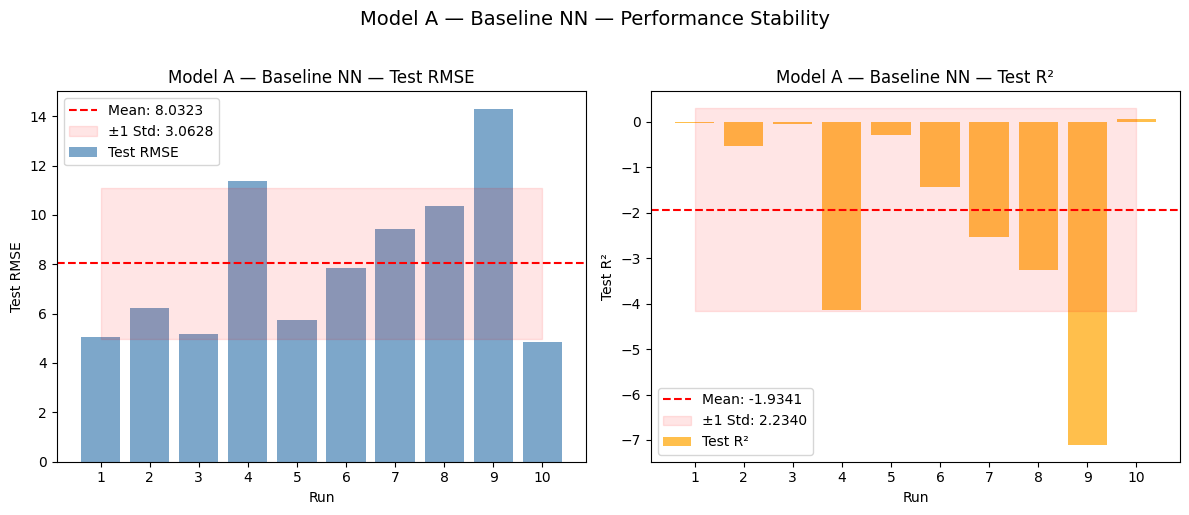

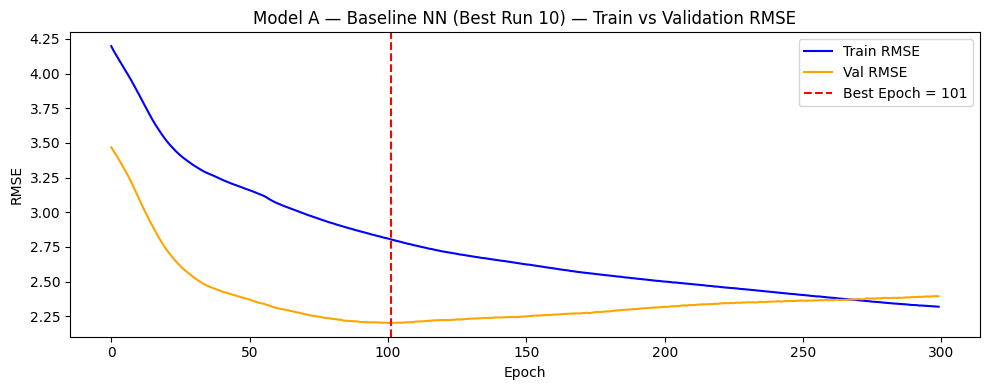

In [8]:

# Model A: Baseline NN

def build_baseline(input_size):
    """Simple feedforward NN — no regularization."""
    model = keras.Sequential([
        layers.Input(shape=(input_size,)),
        layers.Dense(16, activation='relu'),
        layers.Dense(8,  activation='relu'),
        layers.Dense(1)
    ], name='Baseline_NN')

    model.compile(
        optimizer=Adam(0.001),
        loss='mse',
        metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')])
    return model

results_a = run_experiment(build_baseline, X_train, y_train, X_test, y_test, 
                           'Model A — Baseline NN')

plot_stability(results_a)
plot_loss_curve(results_a['best_history'], f"Model A — Baseline NN (Best Run {results_a['best_run']})")




Run 1/10... Train RMSE: 3.1624 | Test RMSE: 7.0769 | Train R²: 0.3996 | Test R²: -0.9885
Run 2/10... Train RMSE: 3.2357 | Test RMSE: 6.0783 | Train R²: 0.3715 | Test R²: -0.4669
Run 3/10... Train RMSE: 3.1289 | Test RMSE: 10.7422 | Train R²: 0.4122 | Test R²: -3.5815
Run 4/10... Train RMSE: 3.2097 | Test RMSE: 9.7693 | Train R²: 0.3815 | Test R²: -2.7893
Run 5/10... Train RMSE: 3.1182 | Test RMSE: 7.9970 | Train R²: 0.4163 | Test R²: -1.5391
Run 6/10... Train RMSE: 3.1888 | Test RMSE: 5.3200 | Train R²: 0.3895 | Test R²: -0.1237
Run 7/10... Train RMSE: 3.1848 | Test RMSE: 7.6419 | Train R²: 0.3910 | Test R²: -1.3186
Run 8/10... Train RMSE: 3.1058 | Test RMSE: 4.5639 | Train R²: 0.4209 | Test R²: 0.1730
Run 9/10... Train RMSE: 3.1302 | Test RMSE: 7.0886 | Train R²: 0.4118 | Test R²: -0.9950
Run 10/10... Train RMSE: 3.1324 | Test RMSE: 11.7226 | Train R²: 0.4109 | Test R²: -4.4560

Model B — NN + L1L2 + Dropout — Over 10 runs:
  Train RMSE — Mean: 3.1597 ± 0.0412
  Test  RMSE — Mean: 7.8

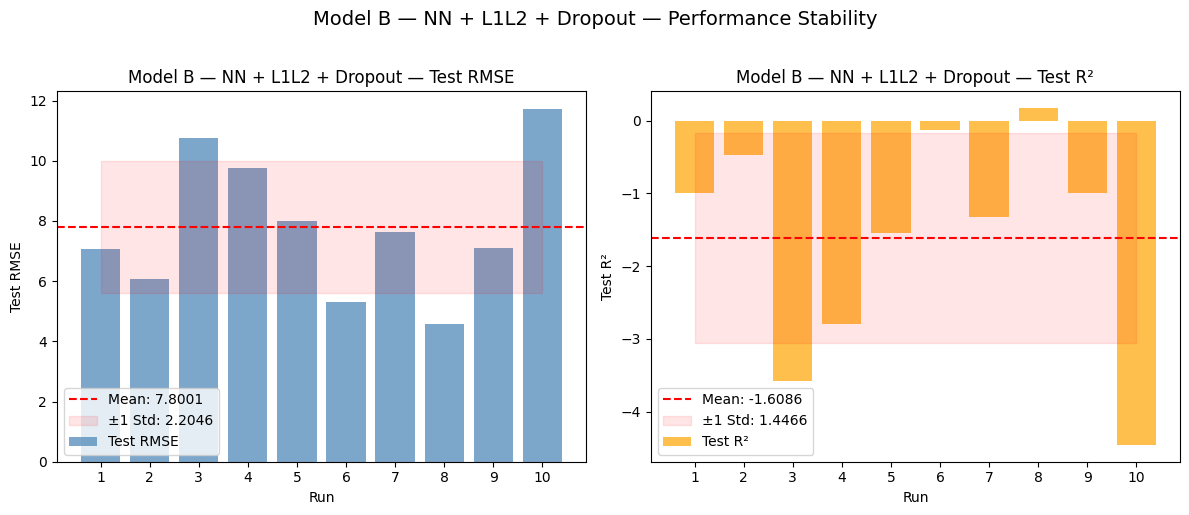

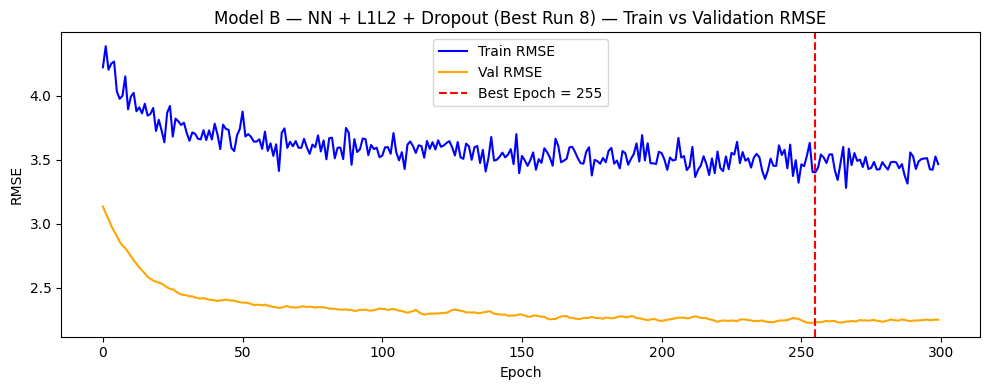

In [9]:
# Model B: NN with regularization + dropout

def build_regularized(input_size, l1=0.001, l2=0.001, dropout=0.3):
    """NN with L1L2 regularization and dropout to reduce overfitting."""
    model = keras.Sequential([
        layers.Input(shape=(input_size,)),

        layers.Dense(16),
        layers.BatchNormalization(),
        layers.Dropout(dropout),

        layers.Dense(8, activation='relu',
                     kernel_regularizer=regularizers.l1_l2(l1=l1, l2=l2)),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(1)
    ], name='Regularized_NN')

    model.compile(
        optimizer=Adam(0.001), 
        loss='mse',
        metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')]
        )
    return model


results_b = run_experiment(build_regularized, X_train, y_train, X_test, y_test,
                           'Model B — NN + L1L2 + Dropout')
plot_stability(results_b)
plot_loss_curve(results_b['best_history'], f"Model B — NN + L1L2 + Dropout (Best Run {results_b['best_run']})")


